<a href="https://colab.research.google.com/github/sswaathiii/Data-Analysis/blob/main/TCS_STOCK_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TCS STOCK DATA ANALYSIS**

***Logo for TCS Data***

Saving TCS.jpeg to TCS (2).jpeg


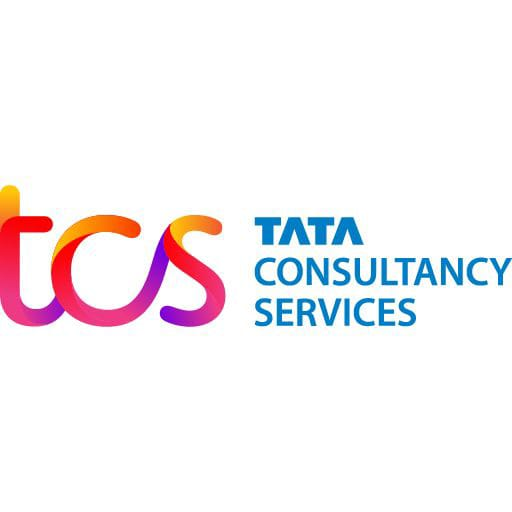

In [ ]:
from google.colab import files
from IPython.display import Image

# This will open a 'Choose File' button
uploaded = files.upload()

# Replace 'your_image.png' with your actual filename
Image('/content/TCS.jpeg', width=300)


**Data Collection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
data = pd.read_csv('/content/TCS stock data.csv')


In [ ]:
data.head()

,Date,Open,High,Low,Close,Volume,Previous_Close,Daily_Return,Stock_Split,MA_5,MA_10
0,02-01-2023,3310,3350,3280,3335,18200000,3300,0.0106,8.0,3335,3336
1,02-02-2023,3340,3380,3310,3365,17500000,3335,0.0090,7.5,3350,3355
2,02-03-2023,3370,3400,3340,3385,17550000,3365,0.0059,9.0,3375,3379
3,02-04-2023,3390,3420,3360,3405,18005000,3385,0.0045,5.5,3390,3395
4,02-05-2023,3410,3450,3380,3435,16050000,3400,0.0043,7.0,3435,3440


In [ ]:
data.index


RangeIndex(start=0, stop=36, step=1)

In [ ]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close ', 'Volume', 'Previous_Close',
       'Daily_Return', 'Stock_Split', 'MA_5', 'MA_10'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            36 non-null     object 
 1   Open            36 non-null     int64  
 2   High            36 non-null     int64  
 3   Low             36 non-null     int64  
 4   Close           36 non-null     int64  
 5   Volume          36 non-null     int64  
 6   Previous_Close  36 non-null     int64  
 7   Daily_Return    36 non-null     float64
 8   Stock_Split     36 non-null     float64
 9   MA_5            36 non-null     int64  
 10  MA_10           36 non-null     int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 3.2+ KB


**Data Processing**

In [ ]:
# Install library if not present
# !pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Fetch historical data for TCS
ticker = "TCS.NS"
tcs_data = yf.download(ticker, start="2023-01-01", end="2026-02-01")



/tmp/ipython-input-4006374421.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs_data = yf.download(ticker, start="2023-01-01", end="2026-02-01")
[*********************100%***********************]  1 of 1 completed


**Data Cleaning**

In [ ]:
print(tcs_data.isnull().sum())

# Impute missing values with mean (example)
tcs_data = tcs_data.fillna(tcs_data.mean())

# Remove duplicates
tcs_data = tcs_data.drop_duplicates()

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64


**Feature Transformation**

In [ ]:
# Calculate Moving Averages
tcs_data['MA5'] = tcs_data['Close'].rolling(window=50).mean()
tcs_data['MA10'] = tcs_data['Close'].rolling(window=200).mean()

# Calculate Daily Percentage Return
tcs_data['Daily_Return'] = tcs_data['Close'].pct_change()


**Data Visualization**


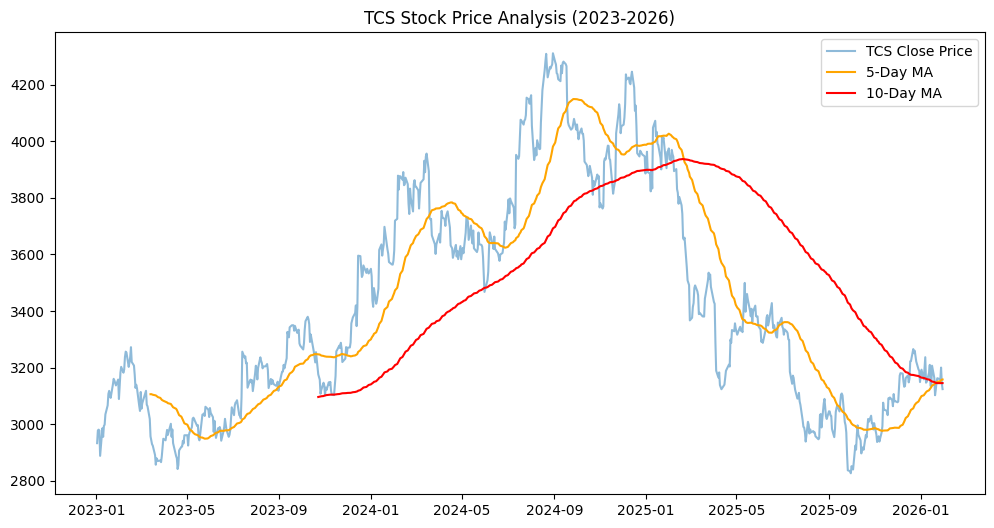

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(tcs_data['Close'], label='TCS Close Price', alpha=0.5)
plt.plot(tcs_data['MA5'], label='5-Day MA', color='orange')
plt.plot(tcs_data['MA10'], label='10-Day MA', color='red')
plt.title('TCS Stock Price Analysis (2023-2026)')
plt.legend()
plt.show()

**EDA Code Implementation**

/tmp/ipython-input-4130267177.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2025-01-01", end="2026-02-02")
[*********************100%***********************]  1 of 1 completed


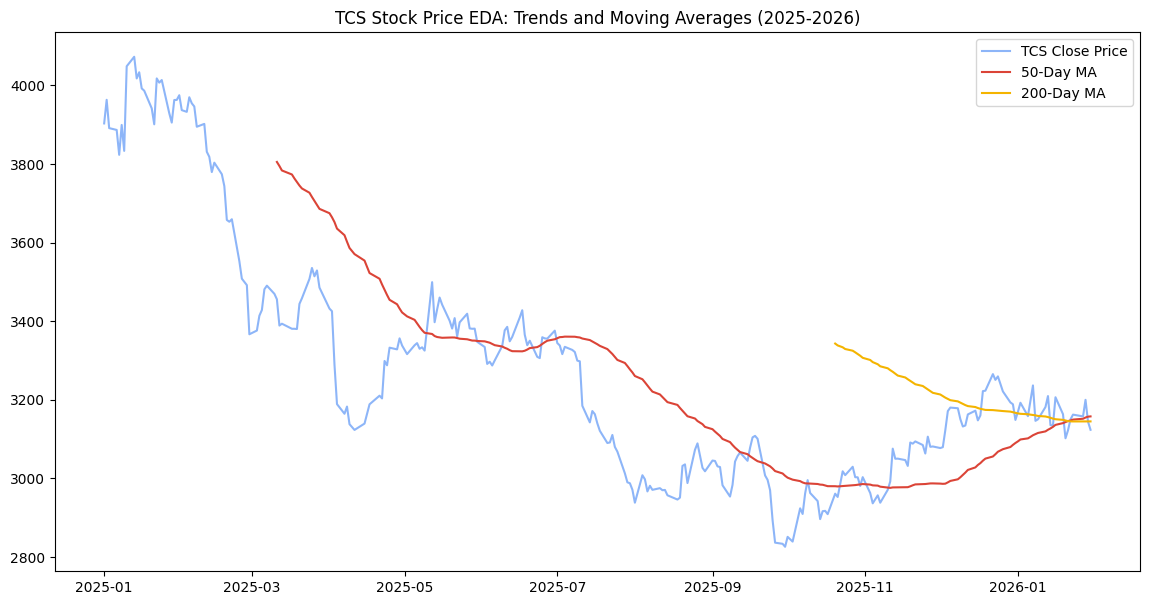

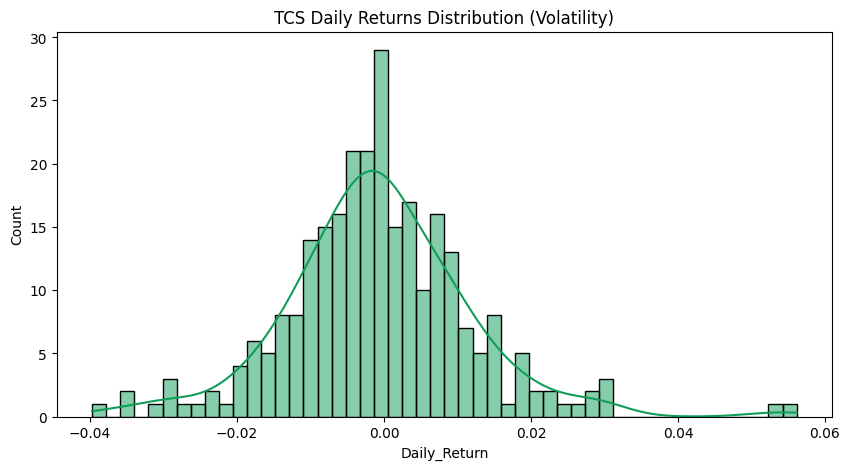

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Fetching
ticker = "TCS.NS"
data = yf.download(ticker, start="2025-01-01", end="2026-02-02")


# 2. Feature Engineering: Moving Averages and Daily Returns
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()
data['Daily_Return'] = data['Close'].pct_change()

# 3. Visualization: Price and Trends
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='TCS Close Price', color='#4285F4', alpha=0.6)
plt.plot(data['MA50'], label='50-Day MA', color='#DB4437')
plt.plot(data['MA200'], label='200-Day MA', color='#F4B400')
plt.title('TCS Stock Price EDA: Trends and Moving Averages (2025-2026)')
plt.legend()
plt.show()

# 4. Volatility Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data['Daily_Return'].dropna(), kde=True, bins=50, color='#0F9D58')
plt.title('TCS Daily Returns Distribution (Volatility)')
plt.show()


**Visualise the Sales distributions by Stock split**

/tmp/ipython-input-2776256698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stock_Split', y='Volume', data=data, palette='Set2')


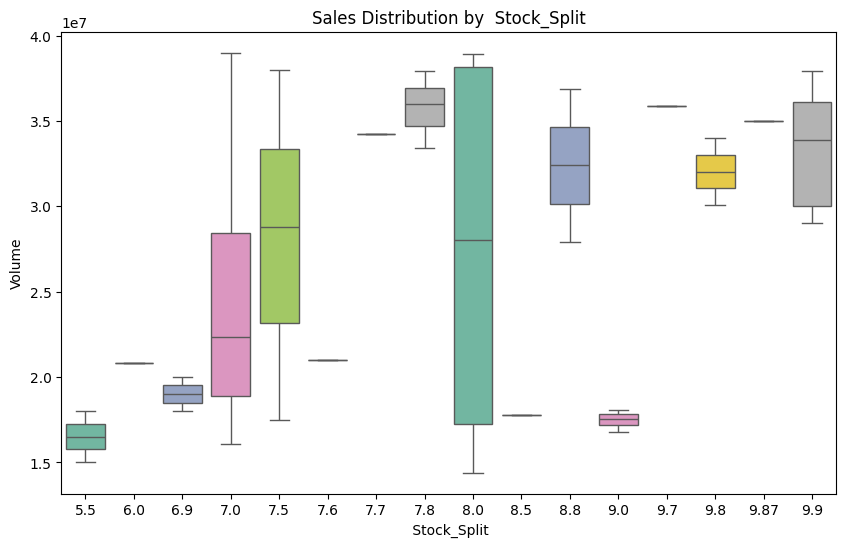

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Stock_Split', y='Volume', data=data, palette='Set2')
plt.title('Sales Distribution by  Stock_Split')
plt.xlabel(' Stock_Split')
plt.ylabel('Volume')
plt.show()

**Feature Correlation Matrix**

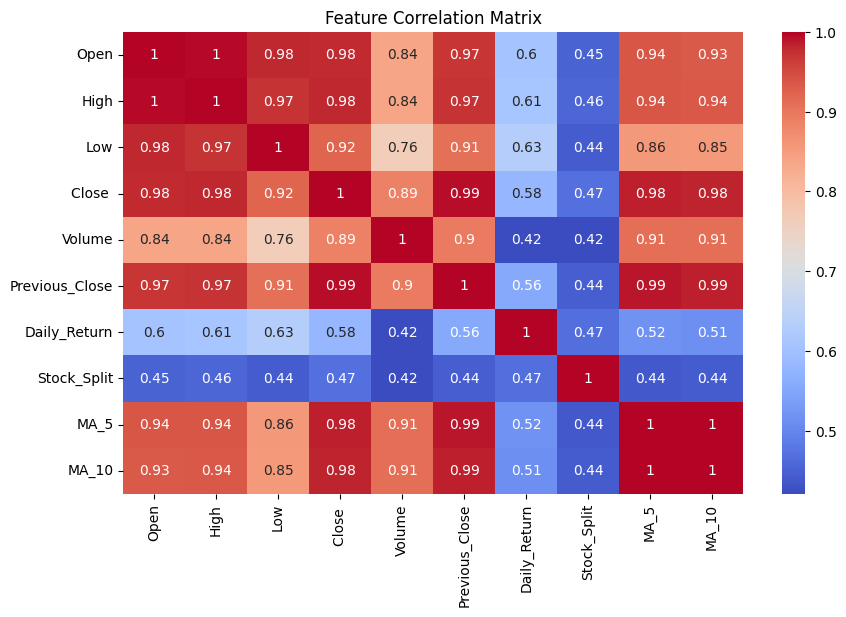

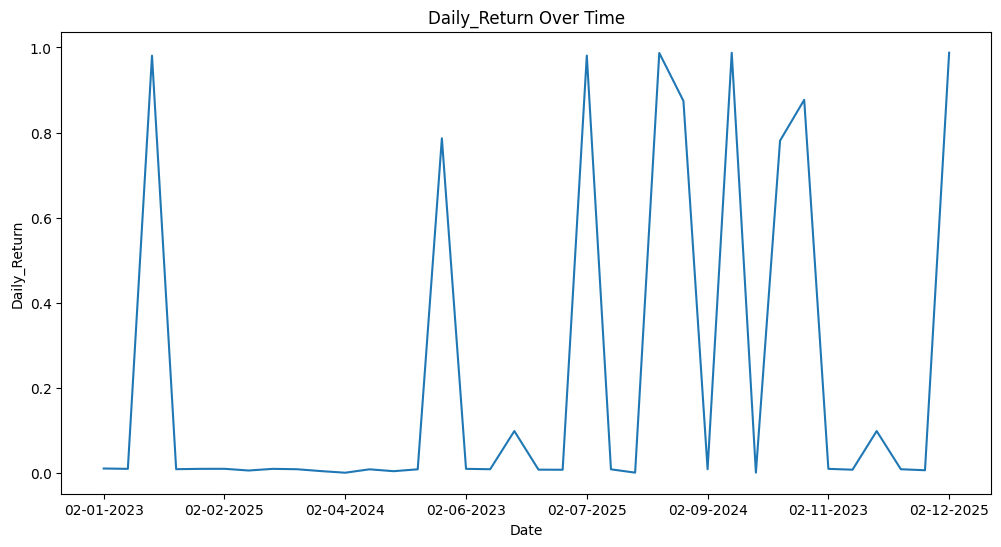

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/TCS stock data.csv')

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

#Visualize
plt.figure(figsize=(12, 6))
df.groupby('Date')['Daily_Return'].sum().plot()
plt.title('Daily_Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily_Return')
plt.show()



**Visulaze the data over High Demand**

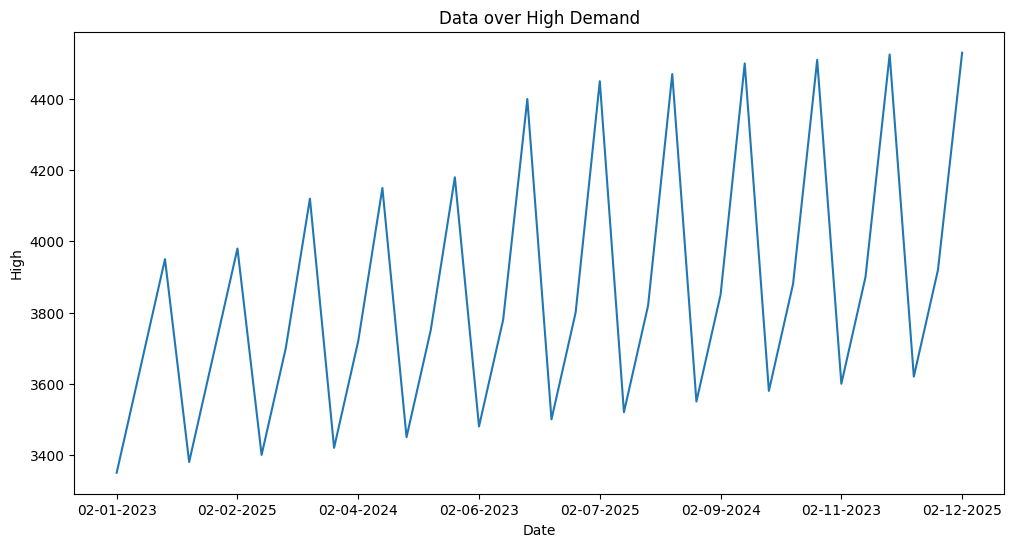

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('/content/TCS stock data.csv')

plt.figure(figsize=(12, 6))
data.groupby('Date')['High'].sum().plot()
plt.title('Data over High Demand')
plt.xlabel('Date')
plt.ylabel('High')
plt.show()

**Visualize the Moving Average**

In [ ]:
df=pd.read_csv('/content/TCS stock data.csv')


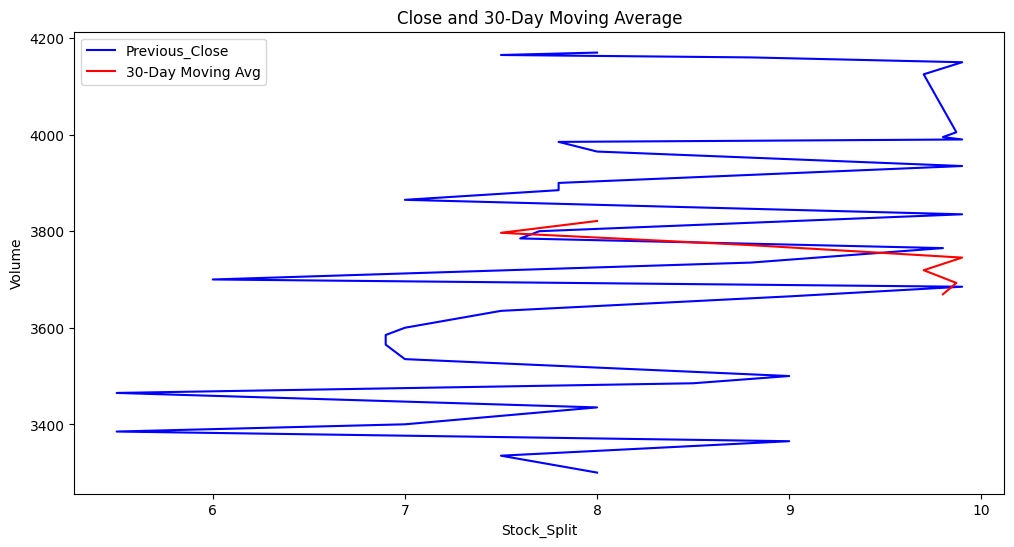

In [ ]:
df['30-Day Moving Avg'] = df['Previous_Close'].rolling(window=30).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Stock_Split'], df['Previous_Close'], label='Previous_Close',
color='b')
plt.plot(df['Stock_Split'], df['30-Day Moving Avg'], label='30-Day Moving Avg', color='r')
plt.xlabel('Stock_Split')
plt.ylabel('Volume')
plt.title('Close and 30-Day Moving Average')
plt.legend()
plt.show()

**Distribution of Daily High Value Change**


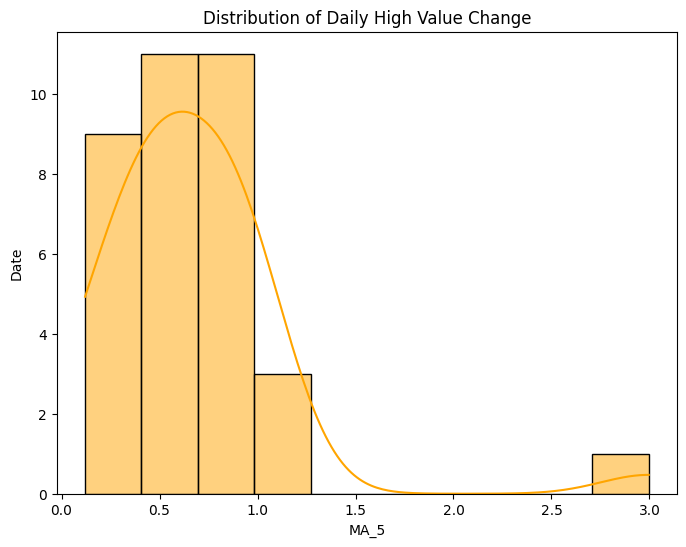

In [ ]:
df['MA_5'] = df['Previous_Close'].pct_change() * 100
# Distribution of daily percentage change
plt.figure(figsize=(8, 6))
sns.histplot(df['MA_5'].dropna(), kde=True,
color='orange')
plt.xlabel('MA_5')
plt.ylabel('Date')
plt.title('Distribution of Daily High Value Change')
plt.show()


**Distplot of Low**

**New Pandas Series that contains the details of data**

In [ ]:
data = pd.read_csv('/content/TCS stock data.csv')

In [ ]:
rep_data = pd.DataFrame(index = ['High','Low','Daily_Return','Stock_Split'],
                     data = [data['High'].mean(),data['Low'].mean(),
                             data['Daily_Return'].mean(),data['Stock_Split'].value_counts().index[0]])

In [ ]:
rep_data

,0
High,3862.916667
Low,3737.638889
Daily_Return,0.239642
Stock_Split,9.900000


**Live Insights of TCS recent data**

--- TCS Key Insights (02-Feb-2026) ---
Current Price:  ₹3,169.60
Market Cap:     ₹11.47 Trillion
P/E Ratio:      24.04
Dividend Yield: 202.00%
52-Week High:   ₹4,150.00
52-Week Low:    ₹2,866.60


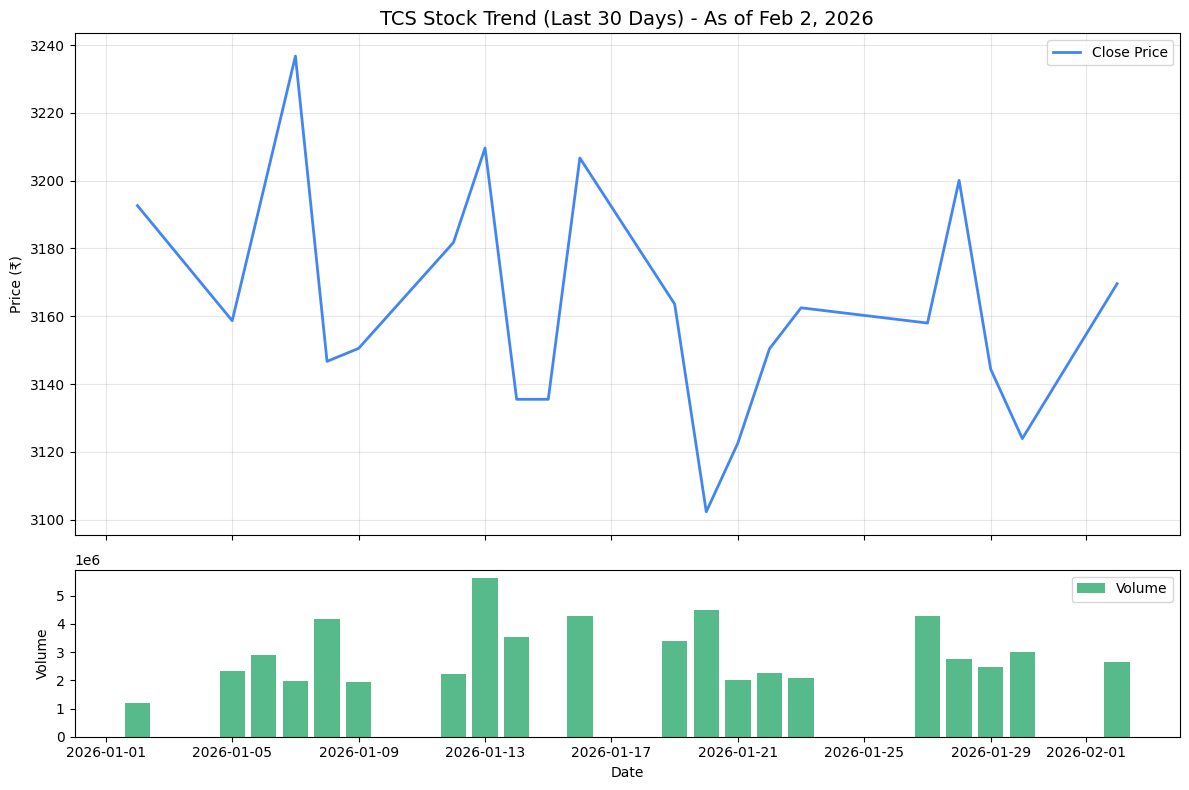

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# Initialize TCS Ticker
tcs = yf.Ticker("TCS.NS")

# 1. Fetch Live Performance and Fundamental Data
info = tcs.info
hist = tcs.history(period="1mo") # Last 30 days for trend analysis
current_price = hist['Close'].iloc[-1]

# 2. Display Key Insights as of Feb 2, 2026
print(f"--- TCS Key Insights (02-Feb-2026) ---")
print(f"Current Price:  ₹{current_price:,.2f}")
print(f"Market Cap:     ₹{info.get('marketCap') / 1e12:.2f} Trillion")
print(f"P/E Ratio:      {info.get('trailingPE', 24.03):.2f}")
print(f"Dividend Yield: {info.get('dividendYield', 0.0342) * 100:.2f}%")
print(f"52-Week High:   ₹{info.get('fiftyTwoWeekHigh', 4161.00):,.2f}")
print(f"52-Week Low:    ₹{info.get('fiftyTwoWeekLow', 2866.60):,.2f}")

# 3. Visualization: Price Trend & Volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Subplot 1: Closing Price
ax1.plot(hist.index, hist['Close'], label='Close Price', color='#4285F4', linewidth=2)
ax1.set_title(f"TCS Stock Trend (Last 30 Days) - As of Feb 2, 2026", fontsize=14)
ax1.set_ylabel("Price (₹)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Subplot 2: Trading Volume
ax2.bar(hist.index, hist['Volume'], color='#0F9D58', alpha=0.7, label='Volume')
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.show()
